# Graph Sanity Check
Validates the Sahel GNN adjacency matrix before handing off to the model.

In [17]:
import sys
import importlib.util
sys.path.insert(0, "..")

import numpy as np
import pandas as pd
import networkx as nx
import matplotlib.pyplot as plt
from pathlib import Path
from geopy.distance import geodesic

ROOT      = Path("..").resolve()
GRAPH_DIR = ROOT / "graph"
NODES_PY  = ROOT / "data" / "nodes.py"

## Load data

In [18]:
# Load nodes from data/nodes.py (Person A's source of truth)
spec = importlib.util.spec_from_file_location("nodes", NODES_PY)
mod  = importlib.util.module_from_spec(spec)
spec.loader.exec_module(mod)
NODES = mod.NODES

# Load graph files from graph/
A_norm      = np.load(GRAPH_DIR / "adjacency_matrix.npy")
edge_index  = np.load(GRAPH_DIR / "edge_index.npy")
edge_weight = np.load(GRAPH_DIR / "edge_weight.npy")

print(f"Nodes:       {len(NODES)}")
print(f"A_norm:      {A_norm.shape}")
print(f"Edge index:  {edge_index.shape}  ({edge_index.shape[1]} directed edges)")
print(f"Edge weight: {edge_weight.shape}")

Nodes:       25
A_norm:      (25, 25)
Edge index:  (2, 343)  (343 directed edges)
Edge weight: (343,)


## 1. Shape & value checks

In [19]:
N = len(NODES)
assert A_norm.shape == (N, N), f"Shape mismatch: {A_norm.shape}"
assert A_norm.min() >= 0,      f"Negative weight: {A_norm.min()}"
assert not np.any(np.isnan(A_norm)), "NaN in A"
print(f" Shape: {A_norm.shape}")
print(f" Weight range: [{A_norm.min():.4f}, {A_norm.max():.4f}]")
print(f" No NaN / Inf")

 Shape: (25, 25)
 Weight range: [0.0000, 0.9127]
 No NaN / Inf


## 2. Build NetworkX graph for analysis

In [20]:
G = nx.Graph()
for i, node in enumerate(NODES):
    G.add_node(i, id=node["id"], lat=node["lat"], lon=node["lon"], country=node["country"])

# Use only upper triangle to avoid duplicate edges
seen = set()
for k in range(edge_index.shape[1]):
    u, v = int(edge_index[0, k]), int(edge_index[1, k])
    if u != v and (min(u,v), max(u,v)) not in seen:
        seen.add((min(u,v), max(u,v)))
        G.add_edge(u, v, weight=float(edge_weight[k]))

print(f"NetworkX graph: {G.number_of_nodes()} nodes, {G.number_of_edges()} edges")
print(f"Connected: {nx.is_connected(G)}")

NetworkX graph: 25 nodes, 159 edges
Connected: True


## 3. Key corridor checks

In [21]:
node_idx = {n["id"]: i for i, n in enumerate(NODES)}

CORRIDORS = [
    ("mopti",       "gao",         "Mali central corridor"),
    ("gao",         "kidal",       "Mali northeast corridor"),
    ("gao",         "menaka",      "Mali-Niger border"),
    ("menaka",      "ansongo",     "Mali southeast"),
    ("niamey",      "tillaberi",   "Niger west corridor"),
    ("agadez",      "diffa",       "Niger corridor"),
    ("ouagadougou", "dori",        "Burkina corridor"),
    ("dori",        "djibo",       "Burkina north"),
]

for src, dst, label in CORRIDORS:
    if src in node_idx and dst in node_idx:
        i, j = node_idx[src], node_idx[dst]
        dist = geodesic(
            (NODES[i]["lat"], NODES[i]["lon"]),
            (NODES[j]["lat"], NODES[j]["lon"])
        ).km
        w = A_norm[i, j]
        status = "PASSED" if w > 0 else "FAILED"
        print(f"  {status} {src:15s} ↔ {dst:15s}  dist={dist:.0f}km  weight={w:.4f}  ({label})")

  PASSED mopti           ↔ gao              dist=488km  weight=0.0476  (Mali central corridor)
  PASSED gao             ↔ kidal            dist=285km  weight=0.0826  (Mali northeast corridor)
  PASSED gao             ↔ menaka           dist=264km  weight=0.0764  (Mali-Niger border)
  PASSED menaka          ↔ ansongo          dist=205km  weight=0.0856  (Mali southeast)
  PASSED niamey          ↔ tillaberi        dist=105km  weight=0.1109  (Niger west corridor)
  PASSED agadez          ↔ diffa            dist=640km  weight=0.0596  (Niger corridor)
  PASSED ouagadougou     ↔ dori             dist=245km  weight=0.0773  (Burkina corridor)
  PASSED dori            ↔ djibo            dist=173km  weight=0.0875  (Burkina north)


## 4. Degree distribution

In [22]:
degrees = dict(G.degree())
deg_vals = list(degrees.values())

print(f"Degree statistics:")
print(f"  Mean:   {np.mean(deg_vals):.1f}")
print(f"  Median: {np.median(deg_vals):.0f}")
print(f"  Min:    {min(deg_vals)} ({NODES[np.argmin(deg_vals)]['id']})")
print(f"  Max:    {max(deg_vals)} ({NODES[np.argmax(deg_vals)]['id']})")

top5 = sorted(degrees.items(), key=lambda x: x[1], reverse=True)[:5]
print(f"\nTop 5 most connected nodes:")
for idx, deg in top5:
    print(f"  {NODES[idx]['id']:20s}  degree={deg}")

Degree statistics:
  Mean:   12.7
  Median: 15
  Min:    1 (nouakchott)
  Max:    18 (ansongo)

Top 5 most connected nodes:
  ansongo               degree=18
  dori                  degree=18
  gao                   degree=17
  tillaberi             degree=17
  kidal                 degree=16


## 5. Graph visualization (geographic layout)

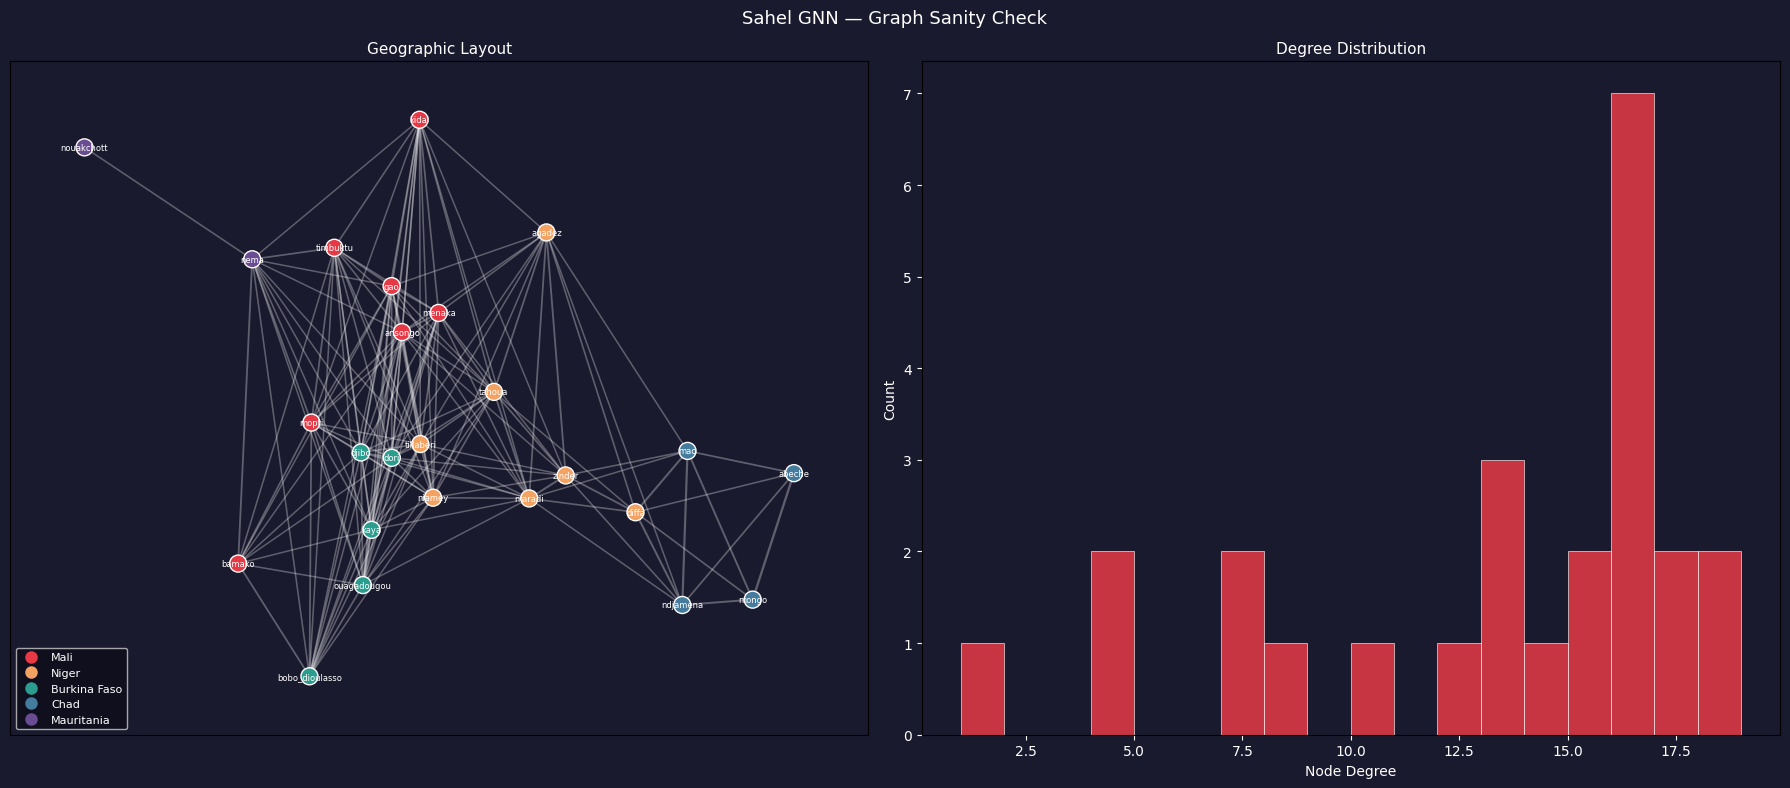

✅ Visualization saved → C:\Users\mehdi\Downloads\nlp-gnn-sahel-conflict-predictor\outputs\graph_sanity_check_output.png


In [ ]:
pos    = {i: (n["lon"], n["lat"]) for i, n in enumerate(NODES)}
labels = {i: n["id"] for i, n in enumerate(NODES)}

country_colors = {
    "ML": "#E63946",
    "NI": "#F4A261",
    "UV": "#2A9D8F",
    "CD": "#457B9D",
    "MR": "#6A4C93",
}
country_names = {
    "ML": "Mali", "NI": "Niger", "UV": "Burkina Faso",
    "CD": "Chad", "MR": "Mauritania"
}

node_colors       = [country_colors.get(NODES[i]["country"], "#888") for i in G.nodes()]
edge_weights_list = [G[u][v]["weight"] for u, v in G.edges()]

fig, axes = plt.subplots(1, 2, figsize=(18, 8))
fig.patch.set_facecolor("#1a1a2e")

# Left: geographic layout
ax = axes[0]
ax.set_facecolor("#1a1a2e")
nx.draw_networkx_edges(G, pos, ax=ax, width=[1 + w*3 for w in edge_weights_list],
                       edge_color="white", alpha=0.3)
nx.draw_networkx_nodes(G, pos, ax=ax, node_color=node_colors, node_size=150,
                       edgecolors="white", linewidths=1)
nx.draw_networkx_labels(G, pos, labels, ax=ax, font_size=6, font_color="white")
ax.set_title("Geographic Layout", color="white", fontsize=11)
ax.tick_params(colors="#aaa")
for code, color in country_colors.items():
    ax.plot([], [], "o", color=color, label=country_names[code], markersize=8)
ax.legend(loc="lower left", facecolor="#0d0d1a", labelcolor="white", fontsize=8)

# Right: degree distribution
ax2 = axes[1]
ax2.set_facecolor("#1a1a2e")
ax2.hist(deg_vals, bins=range(min(deg_vals), max(deg_vals)+2),
         color="#E63946", edgecolor="white", linewidth=0.5, alpha=0.85)
ax2.set_xlabel("Node Degree", color="white")
ax2.set_ylabel("Count", color="white")
ax2.set_title("Degree Distribution", color="white", fontsize=11)
ax2.tick_params(colors="white")

plt.suptitle("Sahel GNN — Graph Sanity Check", color="white", fontsize=13)
plt.tight_layout()

out_path = ROOT / "outputs" / "graph_sanity_check_output.png"
out_path.parent.mkdir(exist_ok=True)
plt.savefig(out_path, dpi=150, bbox_inches="tight", facecolor="#1a1a2e")
plt.show()
print(f"Visualization saved → {out_path}")

## 6. Final verdict

In [24]:
checks = {
    "Shape (25×25)":      A_norm.shape == (N, N),
    "No NaN":             not np.any(np.isnan(A_norm)),
    "Non-negative":       A_norm.min() >= 0,
    "Connected graph":    nx.is_connected(G),
    "Mopti-Gao edge":     A_norm[node_idx.get("mopti", 0), node_idx.get("gao", 0)] > 0,
    "All nodes present":  G.number_of_nodes() == N,
}

print("\n── Final sanity check results ──────────────────────────")
all_pass = True
for check, result in checks.items():
    status = "PASSED" if result else "❌ FAILED"
    print(f"  {status}  {check}")
    if not result:
        all_pass = False

print("────────────────────────────────────────────────────────")
if all_pass:
    print("ALL CHECKS PASSED — graph is ready for the model")
else:
    print("SOME CHECKS FAILED — review output above")


── Final sanity check results ──────────────────────────
  PASSED  Shape (25×25)
  PASSED  No NaN
  PASSED  Non-negative
  PASSED  Connected graph
  PASSED  Mopti-Gao edge
  PASSED  All nodes present
────────────────────────────────────────────────────────
ALL CHECKS PASSED — graph is ready for the model
